In [22]:
#Import the necessary libraries

#Used to work with foldders and file paths
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Detect project root by searching upward for the expected project folders
current_path = Path.cwd() #Identifies from what folder the notebook is being run and lists all folders until it finds the project root 
candidate_roots = [current_path] + list(current_path.parents)

PROJECT_ROOT = None #Create a variable to store the project root path  

"""
Create a loop to check each candidate for the presence of the expected project folders: data, notebooks, and outputs.
If a candidate contains all three folders, it is set as the project root and the loop breaks. If no candidate is found, a FileNotFoundError is raised.
"""
for path in candidate_roots:
    has_data = (path / "data").exists()
    has_notebooks = (path / "notebooks").exists()
    has_outputs = (path / "outputs").exists()
    
    if has_data and has_notebooks and has_outputs:
        PROJECT_ROOT = path
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not detect project root. Expected a folder containing data, notebooks, and outputs."
    )

# Define project folders
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUT_CHARTS = PROJECT_ROOT / "outputs" / "charts"
OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tables"
SRC_DIR = PROJECT_ROOT / "src"
DOCS_DIR = PROJECT_ROOT / "docs"

# Validate required folders
required_folders = {
    "data/raw": DATA_RAW,
    "data/processed": DATA_PROCESSED,
    "outputs/charts": OUTPUT_CHARTS,
    "outputs/tables": OUTPUT_TABLES,
    "src": SRC_DIR,
    "docs": DOCS_DIR,
}

#Verify that all required folders paths exist  
missing_folders = [name for name, path in required_folders.items() if not path.exists()]

#Raise an error in case a required folder is missing, listing the missing folders in the error message
if missing_folders:
    raise FileNotFoundError(f"Missing required folders: {missing_folders}")

#If all folders are found, print the project root and a confirmation message
print("Project root detected:", PROJECT_ROOT)
print("All required folders found.")

Project root detected: c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment
All required folders found.


In [23]:
# Define official raw CSV files
candidate_files = {
    "Orion": DATA_RAW / "orion_eod.csv",
    "Cleanergy": DATA_RAW / "cleanergy_eod.csv",
    "NovaTerra": DATA_RAW / "novaterra_eod.csv",
}

# Validate that all expected files exist
for candidate, path in candidate_files.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing file for {candidate}: {path}")

    print(f"{candidate}: {path.name}")

Orion: orion_eod.csv
Cleanergy: cleanergy_eod.csv
NovaTerra: novaterra_eod.csv


In [ ]:
# Create a dictionary to store the raw CSV data under each company name
raw_data = {}

for candidate, path in candidate_files.items():
    df = pd.read_csv(path)
    raw_data[candidate] = df #Store the raw data in the dictionary under the candidate name as key

    print(candidate) #Print the comapany's name  
    print("File:", path.name) #Print the file name being read for that company
    print("Shape:", df.shape) #Print the shape of the dataframe (rows, columns) 
    print("Columns:", list(df.columns)) #Print the list of variables in the dataframe
    print("\nMissing values:")
    print(df.isna().sum()) #Print the number of missing values for each variable
    print("\nFirst rows:")
    display(df.head()) #Display the first rows of the dataframe to visually inspect the data  

Orion
File: orion_eod.csv
Shape: (1745, 2)
Columns: ['Date', 'Close']

Missing values:
Date     0
Close    0
dtype: int64

First rows:


,Date,Close
0,2019-06-20,100.304717
1,2019-06-21,97.934017
2,2019-06-24,98.542921
3,2019-06-25,97.079801
4,2019-06-26,100.107772


Cleanergy
File: cleanergy_eod.csv
Shape: (2189, 2)
Columns: ['Date', 'Close']

Missing values:
Date     0
Close    0
dtype: int64

First rows:


,Date,Close
0,2018-01-02,7.998515
1,2018-01-03,8.009211
2,2018-01-04,8.279548
3,2018-01-05,8.444102
4,2018-01-08,8.714342


NovaTerra
File: novaterra_eod.csv
Shape: (3519, 2)
Columns: ['Date', 'Close']

Missing values:
Date     0
Close    0
dtype: int64

First rows:


,Date,Close
0,2012-08-31,30.157379
1,2012-09-03,29.589193
2,2012-09-04,29.973003
3,2012-09-05,30.550718
4,2012-09-06,29.520556


In [ ]:
#Create a dictionary to store the cleaned price data under each company name
price_data = {}

#Iterate through the raw datasets 
for candidate, df in raw_data.items():
    clean_df = df.copy() #Create a copy of the raw dataframe to not modify the original data

    clean_df["Date"] = pd.to_datetime(clean_df["Date"]) #Convert the "Date" column to datetime format to facilitate manipulation
    clean_df["Close"] = pd.to_numeric(clean_df["Close"], errors="coerce") #Convert the "Close" column to numeric format; "coerce" converts non-numeric values to NaN

    clean_df = clean_df.dropna(subset=["Date", "Close"]) #Drop rows where we do not have "Date" or "Close" values 
    clean_df = clean_df.sort_values("Date") #Sort the dataframe by date to ensure it is in chronological order; this ensures that returns are compared to the previous trading day
    clean_df = clean_df.set_index("Date") #Set the "Date" column as the index to facilitate time-series analysis

    price_data[candidate] = clean_df #Stored the cleaned dataframe under the company name  

    print(candidate)
    print("Start date:", clean_df.index.min().date())
    print("End date:", clean_df.index.max().date())
    print("Observations:", len(clean_df))
    print()

Orion
Start date: 2019-06-20
End date: 2026-02-25
Observations: 1745

Cleanergy
Start date: 2018-01-02
End date: 2026-05-22
Observations: 2189

NovaTerra
Start date: 2012-08-31
End date: 2026-02-25
Observations: 3519



In [ ]:
# Calculate daily returns from cleaned closing prices
returns_data = {}

#Iterate through the cleaned price datasets to compute daily returns 
for candidate, df in price_data.items():
    returns = df["Close"].pct_change().dropna() #Computes each day's percentage return from closing prices and drops NaN values
    returns_data[candidate] = returns #Stores the returns series under the company name

    print("\n",candidate)
    print("Return observations:", len(returns)) #Print the number of return observations (should be -1 as the initial day cannot be compared to a previous day)
    print("Mean daily return:", round(returns.mean(), 6)) #Compute the average daily return, rounded to 6 decimals
    print("Daily volatility:", round(returns.std(), 6)) #Compute the standard deviation of daily returns as a measure of volatility, rounded to 6 decimals
    print("Minimum daily return:", round(returns.min(), 6)) #Display the minimum daily return, rounded to 6 decimals
    print("Maximum daily return:", round(returns.max(), 6)) #Display the maximum daily return, rounded to 6 decimals


 Orion
Return observations: 1744
Mean daily return: 0.002382
Daily volatility: 0.035641
Minimum daily return: -0.284873
Maximum daily return: 0.259175

 Cleanergy
Return observations: 2188
Mean daily return: 0.000704
Daily volatility: 0.028959
Minimum daily return: -0.072539
Maximum daily return: 0.073783

 NovaTerra
Return observations: 3518
Mean daily return: 0.000212
Daily volatility: 0.020034
Minimum daily return: -0.070738
Maximum daily return: 0.066281


In [ ]:
# Combine returns into one dataframe using all available dates
returns_df_all_dates = pd.DataFrame(returns_data)

print("Combined returns shape using all dates:", returns_df_all_dates.shape)
print("\nMissing values by candidate:")

"""
We compute the number of missing values for each candidate to understand how many dates do not have a return for each company.
This can happen because the company was not traded on that date, or because we do not have data for that date for that company.
"""
print(returns_df_all_dates.isna().sum())
display(returns_df_all_dates.head()) #Print the first rows of the combined returns dataframe

Combined returns shape using all dates: (3580, 3)

Missing values by candidate:
Orion        1836
Cleanergy    1392
NovaTerra      62
dtype: int64


,Orion,Cleanergy,NovaTerra
Date,,,
2012-09-03,NaN,NaN,-0.018841
2012-09-04,NaN,NaN,0.012971
2012-09-05,NaN,NaN,0.019275
2012-09-06,NaN,NaN,-0.033720
2012-09-07,NaN,NaN,-0.029423


In [ ]:
# Remove all of the dates where at least one candidate does not have a return
returns_df_common = returns_df_all_dates.dropna()

print("Common-date returns shape:", returns_df_common.shape)
print("\nMissing values after common-date alignment:")
print(returns_df_common.isna().sum()) #Check that there are no missing values

print("\nCommon period:")
print("Start date:", returns_df_common.index.min().date()) #Indicate the start date of the common period
print("End date:", returns_df_common.index.max().date()) #Indicate the end date of the common period

display(returns_df_common.head())

Common-date returns shape: (1744, 3)

Missing values after common-date alignment:
Orion        0
Cleanergy    0
NovaTerra    0
dtype: int64

Common period:
Start date: 2019-06-21
End date: 2026-02-25


,Orion,Cleanergy,NovaTerra
Date,,,
2019-06-21,-0.023635,-0.033314,0.005726
2019-06-24,0.006217,0.038950,-0.025923
2019-06-25,-0.014848,0.040512,0.001695
2019-06-26,0.031191,-0.021276,-0.019720
2019-06-27,0.013675,-0.059086,0.026859


In [ ]:
#Create constants to indicate the assumptions that we established for the computation of risk and return metrics
TRADING_DAYS = 252
RISK_FREE_RATE = 0.03
POSITION_SIZE = 5_000

"""
Create a reusable function to compute all key metrics for a given candidate
    candidate: a parameter to indicate the name of the company analysed
    prices: a series with the closing prices of the company for the common period
    returns: a series with the daily returns of the company for the common period
"""
def calculate_metrics(candidate, prices, returns):
    """
    Calculate core risk/return metrics for one candidate.
    Uses simple daily returns and closing prices.
    """
    start_price = prices.iloc[0] #Select the first closing price in the dataset
    end_price = prices.iloc[-1] #Select the last closing price in the dataset 
    n_days = len(returns) #Estalish the number of days in the period

    cumulative_return = end_price / start_price - 1 #Measures total return over the full sample period
    annualized_return = (end_price / start_price) ** (TRADING_DAYS / n_days) - 1 #Convert the return from the period into an annualized return 
    annualized_volatility = returns.std() * np.sqrt(TRADING_DAYS) #Compute the annualised volatility from daily returns 

    sharpe = (annualized_return - RISK_FREE_RATE) / annualized_volatility #Compute the Sharpe ratio to measure risk-adjusted return

    cumulative_growth = (1 + returns).cumprod() #Create a growth index from daily returns
    drawdown = cumulative_growth / cumulative_growth.cummax() - 1 #Compute the drawdown as the percentage decline from the previous maximum of the growth index
    max_drawdown = drawdown.min() #Identify the worst fall in the period

    #Compute the historical 95% VaR as the negative of the 5th percentile of returns; the negative sign is used to obtain a positive value
    var_95 = -np.percentile(returns, 5) 
    #Compute the historical 95% CVaR as the negative of the average of returns that are below the 5th percentile; the negative sign is used to obtain a positive value
    cvar_95 = -returns[returns <= np.percentile(returns, 5)].mean() 

    skewness = stats.skew(returns) #Measure the asymmetry of the return distribution
    excess_kurtosis = stats.kurtosis(returns) #Measure the "tailedness" of the return distribution

    #The function returns a dictionary containing all computed metrics for the candidate, which can be easily converted into a dataframe 
    return {
        "Candidate": candidate,
        "Start Date": prices.index.min().date(),
        "End Date": prices.index.max().date(),
        "Obs.": n_days,
        "Cumulative Return": cumulative_return,
        "Ann. Return": annualized_return,
        "Ann. Volatility": annualized_volatility,
        "Sharpe": sharpe,
        "Max Drawdown": max_drawdown,
        "VaR 95%": var_95,
        "VaR 95% €": var_95 * POSITION_SIZE, #Compute the VaR in euros by multiplying the VaR in returns by the position size
        "CVaR 95%": cvar_95,
        "CVaR 95% €": cvar_95 * POSITION_SIZE, #Compute the CVaR in euros by multiplying the CVaR in returns by the position size
        "Skewness": skewness,
        "Excess Kurtosis": excess_kurtosis,
    }

#Create an empty list to store the metrics for each candidate
metrics = []

#Iterate through the candidates 
for candidate in price_data:
    prices = price_data[candidate]["Close"] #Select the closing prices for the candidate from the cleaned price data
    returns = returns_data[candidate] #Select the daily returns for the candidate from the returns data computed from the cleaned price data
    metrics.append(calculate_metrics(candidate, prices, returns))

#Convert the list of metrics into a dataframe 
metrics_df = pd.DataFrame(metrics)

display(metrics_df)

,Candidate,Start Date,End Date,Obs.,Cumulative Return,Ann. Return,Ann. Volatility,Sharpe,Max Drawdown,VaR 95%,VaR 95% €,CVaR 95%,CVaR 95% €,Skewness,Excess Kurtosis
0,Orion,2019-06-20,2026-02-25,1744,19.759640,0.550002,0.565781,0.919087,-0.627577,0.057765,288.825765,0.082326,411.628726,-0.342202,5.573486
1,Cleanergy,2018-01-02,2026-05-22,2188,0.862785,0.074275,0.459702,0.096313,-0.930443,0.048348,241.739693,0.055847,279.237428,-0.004552,-0.585546
2,NovaTerra,2012-08-31,2026-02-25,3518,0.041290,0.002902,0.318026,-0.085205,-0.874838,0.032928,164.638674,0.041191,205.957451,0.023569,0.033756


In [ ]:
metrics_display = metrics_df.copy() #Create a copy of the metrics dataframe to format values for display without modifying the original dataframe

#Select variables in percentage format 
percent_cols = [
    "Cumulative Return",
    "Ann. Return",
    "Ann. Volatility",
    "Max Drawdown",
    "VaR 95%",
    "CVaR 95%",
]

#Select variables in euro format
euro_cols = [
    "VaR 95% €",
    "CVaR 95% €",
]

#Iterate through the percentage variables to format them as percentages with 2 decimals for display
for col in percent_cols:
    metrics_display[col] = metrics_display[col].map(lambda x: f"{x:.2%}")

#Iterate through the euro variables to format them as euros with 2 decimals for display
for col in euro_cols:
    metrics_display[col] = metrics_display[col].map(lambda x: f"€{x:,.2f}")

#Format the rest of the variables with 2 decimals for display
metrics_display["Sharpe"] = metrics_display["Sharpe"].map(lambda x: f"{x:.2f}")
metrics_display["Skewness"] = metrics_display["Skewness"].map(lambda x: f"{x:.2f}")
metrics_display["Excess Kurtosis"] = metrics_display["Excess Kurtosis"].map(lambda x: f"{x:.2f}")

display(metrics_display)

,Candidate,Start Date,End Date,Obs.,Cumulative Return,Ann. Return,Ann. Volatility,Sharpe,Max Drawdown,VaR 95%,VaR 95% €,CVaR 95%,CVaR 95% €,Skewness,Excess Kurtosis
0,Orion,2019-06-20,2026-02-25,1744,1975.96%,55.00%,56.58%,0.92,-62.76%,5.78%,€288.83,8.23%,€411.63,-0.34,5.57
1,Cleanergy,2018-01-02,2026-05-22,2188,86.28%,7.43%,45.97%,0.10,-93.04%,4.83%,€241.74,5.58%,€279.24,-0.00,-0.59
2,NovaTerra,2012-08-31,2026-02-25,3518,4.13%,0.29%,31.80%,-0.09,-87.48%,3.29%,€164.64,4.12%,€205.96,0.02,0.03


In [ ]:
# Export raw numeric metrics for future analysis
raw_metrics_path = OUTPUT_TABLES / "candidate_metrics_raw.csv"
metrics_df.to_csv(raw_metrics_path, index=False)

# Export formatted metrics for review / presentation
formatted_metrics_path = OUTPUT_TABLES / "candidate_metrics_formatted.csv"
metrics_display.to_csv(formatted_metrics_path, index=False)

#Display the paths where the raw and formatted metrics have been exported
print("Exported raw metrics to:")
print(raw_metrics_path)

print("\nExported formatted metrics to:")
print(formatted_metrics_path)

Exported raw metrics to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\candidate_metrics_raw.csv

Exported formatted metrics to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\candidate_metrics_formatted.csv


In [ ]:
#Define the export path and file name for the Excel workbook
excel_metrics_path = OUTPUT_TABLES / "candidate_metrics.xlsx"

#Open an Excel writer object using the openpyxl library
with pd.ExcelWriter(excel_metrics_path, engine="openpyxl") as writer:
    metrics_df.to_excel(writer, sheet_name="Raw Metrics", index=False) #Create a sheet in the Excel workbook with the raw numeric metrics
    metrics_display.to_excel(writer, sheet_name="Formatted Metrics", index=False) #Create a sheet in the Excel workbook with the formatted metrics

#Indicate the file where the Excel workbook have been imported to
print("Exported Excel metrics workbook to:")
print(excel_metrics_path)

Exported Excel metrics workbook to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\candidate_metrics.xlsx


In [ ]:
correlation_matrix = returns_df_common.corr() #Compute a correlation matrix of daily returns for the candidates using the common-date returns dataframe

display(correlation_matrix) #Display the correlation matrix 

#Define the export path and file name for the correlation matrix CSV file
correlation_path = OUTPUT_TABLES / "candidate_return_correlations.csv" 
correlation_matrix.to_csv(correlation_path) #Export the correlation matrix to a CSV file 

#Indicate the folder where the correlation matrix has been exported to
print("Exported correlation matrix to:")
print(correlation_path)

,Orion,Cleanergy,NovaTerra
Orion,1.000000,-0.019797,0.066859
Cleanergy,-0.019797,1.000000,0.005236
NovaTerra,0.066859,0.005236,1.000000


Exported correlation matrix to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\tables\candidate_return_correlations.csv


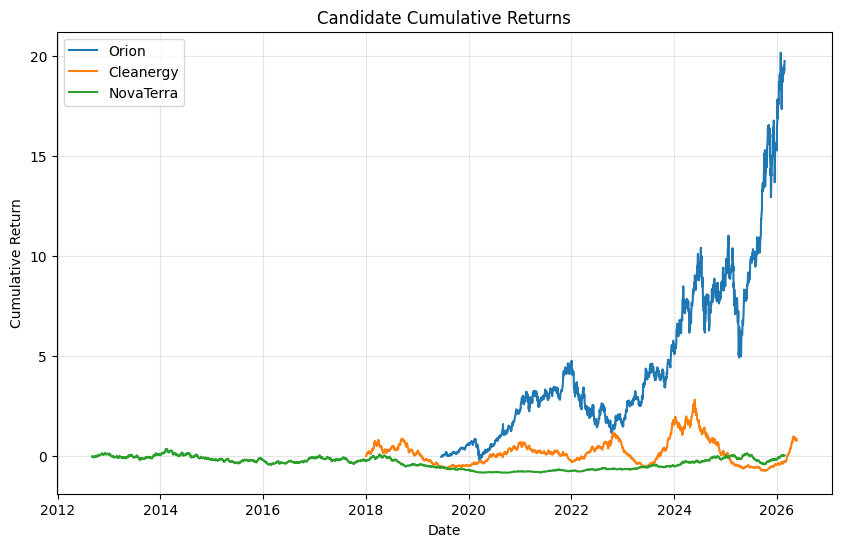

Exported chart to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\charts\candidate_cumulative_returns.png


In [ ]:
#Create a dictionary to store the cumulative returns for each candidate, which will be used to plot the growth of 1€ invested in each candidate over time
cumulative_returns = {}

#Iterate through the candidates' returns to compute the cumulative return for each candidate
for candidate, returns in returns_data.items():
    cumulative_returns[candidate] = (1 + returns).cumprod() - 1 

#Create a dataset that contains the cumulative returns for each candidate
cumulative_returns_df = pd.DataFrame(cumulative_returns)

#Create a figure to plot the cumulative returns of each candidate over time, which represents the growth of 1€ invested in each candidate over time
plt.figure(figsize=(10, 6))

#Iterate through the candidates to plot the cumulative return of each candidate over time in the same chart for comparison
for candidate in cumulative_returns_df.columns:
    plt.plot(cumulative_returns_df.index, cumulative_returns_df[candidate], label=candidate)

plt.title("Candidate Cumulative Returns") #Create a title for the chart
plt.xlabel("Date") #Indicate the name of the variable in the x-axis
plt.ylabel("Cumulative Return") #Indicate the name of the variable in the y-axis
plt.legend() #Create a legend to identify each candidate's line in the chart
plt.grid(True, alpha=0.3) #Add a grid to the chart

chart_path = OUTPUT_CHARTS / "candidate_cumulative_returns.png" #Create a path to export the cumulative returns chart
plt.savefig(chart_path, dpi=300, bbox_inches="tight") #Export the cumulative returns chart to a PNG file with high resolution (300 dpi) and tight bounding box to minimize whitespace
plt.show() #Display the graph

#Indicate the folder where the plot has been exported to
print("Exported chart to:")
print(chart_path)

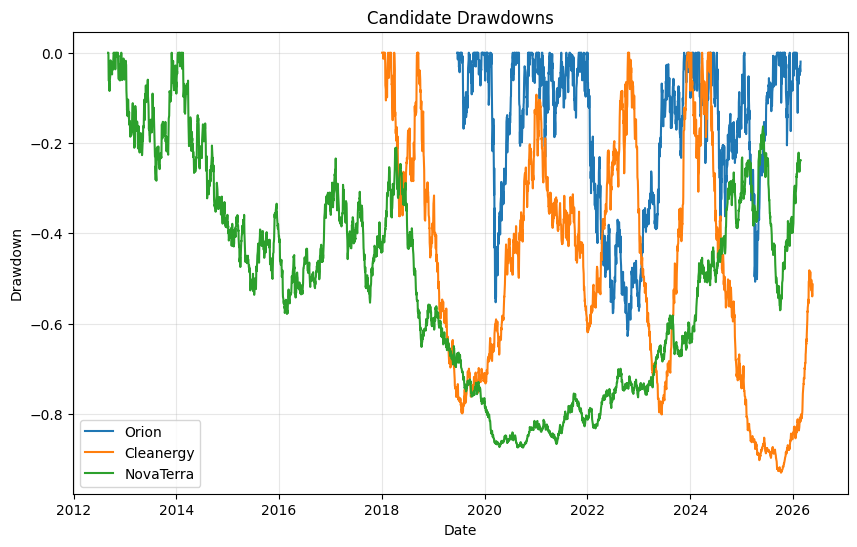

Exported chart to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\charts\candidate_drawdowns.png


In [ ]:
#Create a dictionary to store the drawdowns series for each candidate, which will be used to plot the drawdown of 1€ invested in each candidate over time
drawdowns = {}

#Iterate through the candidates' returns to compute the drawdown for each candidate
for candidate, returns in returns_data.items():
    cumulative_growth = (1 + returns).cumprod() #Create a growth index from daily returns to compute the drawdown
    drawdowns[candidate] = cumulative_growth / cumulative_growth.cummax() - 1 #Compute the drawdown as the percentage decline from the previous maximum of the growth index

#Create a dataset that contains the drawdown series for each candidate
drawdowns_df = pd.DataFrame(drawdowns)

#Create a figure to plot the drawdown of each candidate over time, which represents the percentage decline from the previous maximum of 1€ invested in each candidate over time
plt.figure(figsize=(10, 6))

for candidate in drawdowns_df.columns:
    plt.plot(drawdowns_df.index, drawdowns_df[candidate], label=candidate)

plt.title("Candidate Drawdowns") #Create a title for the chart
plt.xlabel("Date") #Indicate the name of the variable in the x-axis
plt.ylabel("Drawdown") #Indicate the name of the variable in the y-axis
plt.legend() #Create a legend to identify each candidate's line in the chart
plt.grid(True, alpha=0.3) #Add a grid to the chart

#Create a path to export the drawdowns chart 
chart_path = OUTPUT_CHARTS / "candidate_drawdowns.png"
#Export the drawdowns chart to a PNG file with high resolution (300 dpi) and tight bounding box to minimize whitespace
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show() #Display the graph

#Indicate the folder where the plot has been exported to
print("Exported chart to:")
print(chart_path)

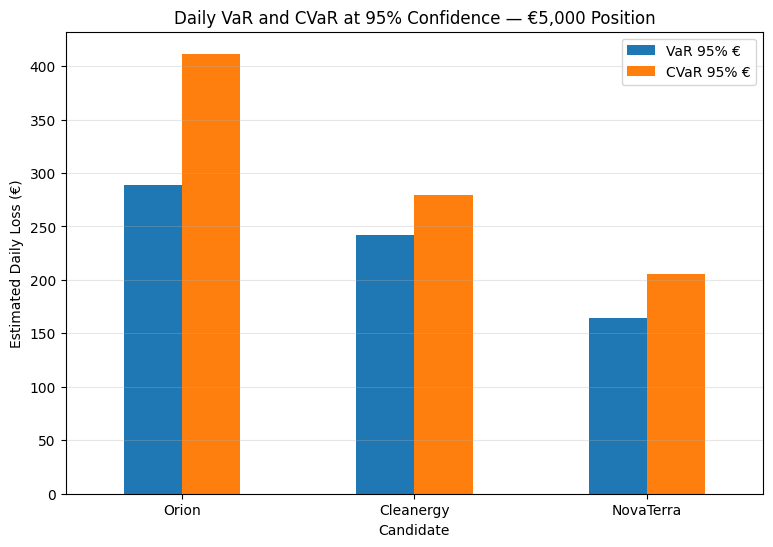

Exported chart to:
c:\Users\Usuario\OneDrive - IE University\2nd year\EDEN fund\Technical Assessment\outputs\charts\candidate_var_cvar_eur.png


In [ ]:
#Create a dataset only using the euro values for VaR and CVaR to plot a bar chart comparing the estimated daily loss in euros for each candidate at 95% confidence
var_cvar_chart_data = metrics_df.set_index("Candidate")[["VaR 95% €", "CVaR 95% €"]]

#Create a bar chart to compare the estimated daily loss in euros for each candidate at 95% confidence, using the dataset created with only the euro values for VaR and CVaR
ax = var_cvar_chart_data.plot(kind="bar", figsize=(9, 6))

plt.title("Daily VaR and CVaR at 95% Confidence — €5,000 Position") #Create a title for the chart
plt.xlabel("Candidate") #Indicate the name of the variable in the x-axis
plt.ylabel("Estimated Daily Loss (€)") #Indicate the name of the variable in the y-axis
plt.xticks(rotation=0) #Prevents axis from being rotated
plt.grid(True, axis="y", alpha=0.3) #Add a grid to the chart (only in the y-axis)

#Create a path and file name to export the VaR and CVaR chart
chart_path = OUTPUT_CHARTS / "candidate_var_cvar_eur.png"
#Export the VaR and CVaR chart to a PNG file with high resolution and tight bounding box to minimize whitespace
plt.savefig(chart_path, dpi=300, bbox_inches="tight") 
plt.show()

#Indicate the path where the chart has been exported to
print("Exported chart to:")
print(chart_path)

## Preliminary Quant Interpretation

The quantitative analysis uses the provided candidate CSV files as the primary source. Main metrics are based on simple daily returns from closing prices. Annualized return is calculated geometrically, annualized volatility assumes 252 trading days, and Sharpe ratios use a 3% annual risk-free rate assumption.

The metrics table compares realized return, volatility, Sharpe ratio, maximum drawdown, daily VaR, daily CVaR, skewness, and excess kurtosis for Orion, Cleanergy, and NovaTerra.

The cumulative return and drawdown charts are used to separate upside performance from downside risk. Correlation analysis is calculated only on the common overlapping date period.